# Project 4: Differential Privacy
Bach Nguyen

This project explore 2 different Secure Multi-Party Computation (SMPC) approaches and Differential Privacy.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import phe.paillier as paillier
import time
import random
from Crypto.Util.number import getPrime

### 1. Setting up the random seed and randomizer function

In [60]:
# Setting the random seed
np.random.seed(42)
rng = np.random.default_rng(42)
def randomizer(n, min_val, max_val):
    """
    Generate a list of random integer values within a specified range.

    Input:
        n (int): Number of random integers to generate.
        min_val (int): The minimum possible integer value (inclusive).
        max_val (int): The maximum possible integer value (exclusive).

    Output:
        numpy.ndarray: An array of randomly generated integers 
                       uniformly distributed between min_val and max_val.
    """
    values = rng.integers(low = min_val, high = max_val, size = n)
    return values

### 2. Function to calculate the mean with no encryption

In [61]:
def baseline_mean(temp_list):
    """
    Compute the average (mean) of a given list of integer values 
    as a non-encrypted baseline for performance comparison.

    Input:
        temp_list (list of int): A pre-generated list of integer values 
                                 to be used for mean computation.

    Output:
        tuple:
            - float: The computation time (in seconds) required to calculate the mean.
            - float: The calculated average
    """
    # Get the start time
    t0 = time.perf_counter()

    # Calculate the mean
    average = np.mean(temp_list)

    # Get the end time
    t1 = time.perf_counter()

    # Compute elapsed time
    computation_time = t1 - t0
    return computation_time, average

### 3. Function to calculate the mean with additively homomorphic Paillier encryption scheme

In [62]:
def paillier_mean(temp_list, public_key, private_key):
    """
    Compute the average (mean) of a given list of integer values 
    using the Paillier homomorphic encryption scheme for secure computation.

    Input:
        temp_list (list of int): A pre-generated list of integer values 
                                 to be used for encrypted mean computation.
        public_key (PaillierPublicKey): Public key used for encryption.
        private_key (PaillierPrivateKey): Private key used for decryption.

    Output:
        tuple:
        - float: The computation time (in seconds) required for encrypted mean calculation.
        - float: The mean of the sum of decrypted values
        - dict:  Phase timings (seconds) with keys:
                     {"enc": encrypt_all, "add": homomorphic_add, "dec": decrypt_sum, "avg": finalize_mean}
    """
    phases = {}
    # Get the start time
    t_start = time.perf_counter()
    # Encrypt each value using the Paillier public key
    encrypted_values = [public_key.encrypt(int(i)) for i in temp_list]
    
    t1 = time.perf_counter()
    phases["enc"] = t1 - t_start

    t2 = time.perf_counter()
    # Compute the encrypted sum (homomorphic addition)
    encrypted_sum = sum(encrypted_values)
    t3 = time.perf_counter()
    phases["add"] = t3 - t2

    t4 = time.perf_counter()
    # Decrypt the result and compute the mean
    decrypted_sum = private_key.decrypt(encrypted_sum)
    t5 = time.perf_counter()
    phases["dec"] = t5 - t4

    t6 = time.perf_counter()
    average = decrypted_sum / len(temp_list)
    t_end = time.perf_counter()
    phases["mean"] = t_end - t6

    # Calculate the total computation time
    computation_time = t_end - t_start
    return computation_time, average, phases


### 4. Functions to calculate the mean with Shamir's secret sharing

In [63]:
def mod_inverse(a, p):
    """
    Compute the modular multiplicative inverse of a modulo p.

    Input:
        a (int): The integer whose modular inverse is to be computed.
        p (int): The prime modulus.

    Output:
        int: The modular inverse of a modulo p.
    """
    return pow(a, -1, p)

def shamir_shares(secret, n, t, p):
    """
    Generate n shares of a secret using Shamir’s Secret Sharing scheme.

    Input:
        secret (int): The secret value to be shared.
        n (int): Total number of shares (parties) to generate.
        t (int): Threshold number of shares required to reconstruct the secret.
        p (int): A large prime modulus for modular arithmetic.

    Output:
        list of tuples: Each tuple is (share index, share value modulo p).
    """
    coeffs = [secret] + [random.randint(1, p - 1) for _ in range(t - 1)]
    shares = []
    for x in range(1, n + 1):
        y = 0
        for i, c in enumerate(coeffs):
            y += c * pow(x, i, p)
        shares.append((x, y % p))
    return shares

def shamir_reconstruct(shares, t, p):
    """
    Reconstruct the secret from t shares using Lagrange interpolation at x=0.

    Input:
        shares (list of tuples): A list of (share index, share value modulo p).
        t (int): Threshold number of shares required for reconstruction.
        p (int): Prime modulus used in share generation.

    Output:
        int: The reconstructed secret value modulo p.
    """
    total = 0
    for i in range(t):
        xi, yi = shares[i]
        num, den = 1, 1
        for j in range(t):
            if i != j:
                xj, _ = shares[j]
                num = (num * -xj) % p
                den = (den * (xi - xj)) % p
        lagrange = (num * mod_inverse(den, p)) % p
        total = (total + yi * lagrange) % p
    return total

def shamir_mean(values, n, t, p):
    """
    Securely compute the average of a list of values using Shamir’s Secret Sharing scheme.

    Input:
        values (list of int): The list of secret integer values to be averaged.
        n (int): Total number of shares (parties) for each secret.
        t (int): Threshold number of shares required for reconstruction.
        p (int): A large prime modulus for modular arithmetic.

    Output:
        tuple:
            - float: The computation time (in seconds) required to securely compute the mean.
            - float: The mean of the sum of reconstructed values
            - dict:  Phase timings (seconds) with keys:
                     {"share": generate_all_shares,
                      "agg":   per_party_aggregation,
                      "rec":   reconstruct_total_sum,
                      "avg":   finalize_mean}
    """
    # Get the start time
    phases = {}
    t_start = time.perf_counter()

    # Generate shares for each secret
    all_shares = [shamir_shares(v, n, t, p) for v in values]
    t1 = time.perf_counter()
    phases["share"] = t1 - t_start

    # Each party sums its shares locally
    t2 = time.perf_counter()
    summed_shares = []
    for i in range(n):
        x = all_shares[0][i][0]  # same across all secrets
        total_y = sum(secret[i][1] for secret in all_shares) % p
        summed_shares.append((x, total_y))
    t3 = time.perf_counter()
    phases["agg"] = t3 - t2
    
    # Reconstruct total sum using only t of the aggregated shares
    t4 = time.perf_counter()
    reconstructed_sum = shamir_reconstruct(summed_shares[:t], t, p)
    t5 = time.perf_counter()
    phases["rec"] = t5 - t4

    t6 = time.perf_counter()
    average = reconstructed_sum / n   

    # Get the end time
    t_end = time.perf_counter()
    phases["mean"] = t_end - t6
    
    # Calculate total computation time
    computation_time = t_end - t_start
    return computation_time, average, phases

### 5. Functions to implement Differential Privacy

In [64]:
def dp_mean(temp_list, epsilon, rng):
    """
    Compute a differentially private mean using the Laplace mechanism (ε-DP),
    returning both runtime and the noisy mean value.

    Input:
        temp_list (list of int): Pre-generated list of integer values.
        epsilon (float): Privacy budget ε (>0).
        rng (np.random.Generator): RNG for reproducibility (used to sample Laplace noise).

    Output:
        tuple:
            - float: Computation time (in seconds) to compute the DP mean.
            - float: The DP mean value (mean + Laplace noise).
    """
    # Start timing
    phases = {}
    t_start = time.perf_counter()

        # Compute true mean
    true_mean = float(np.mean(temp_list))
    t1 = time.perf_counter()
    phases["mean"] = t_start - t1

    # Laplace noise scale for mean: (max - min) / (n * epsilon)
    t2 = time.perf_counter()
    n = len(temp_list)
    sensitivity = (max(temp_list) - min(temp_list)) / n
    t3 = time.perf_counter()
    phases["sensitivity"] = t3 - t2
    
    # Sample Laplace noise and add to mean
    t4 = time.perf_counter()
    noise = rng.laplace(0.0, sensitivity / epsilon)
    average = true_mean + noise  

    # End timing
    t_end = time.perf_counter()
    phases["noise"] = t_end - t4

    # Calculate total computation time
    computation_time = t_end - t_start
    return computation_time, average, phases

### 6. Testing Function

In [67]:
def full_test(n_list, min_val, max_val, epsilon, rng):
    """
    Run performance comparison tests across Baseline, Paillier, and Shamir mean computations
    using the same dataset for each method.

    Input:
        n_list (list of int): List of sample sizes (number of random integers) to test.
        min_val (int): Minimum integer value for random number generation.
        max_val (int): Maximum integer value for random number generation.

    Output:
        pandas.DataFrame: A DataFrame containing columns:
            - "n" (sample size)
            - "Baseline" (runtime in seconds)
            - "Paillier" (runtime in seconds)
            - "Shamir" (runtime in seconds)
    """
    results = []
    total_phases = []
    for n in n_list:
        # Generate consistent random dataset for this n
        values = randomizer(n, min_val, max_val).tolist()

        # Paillier keys (3072-bit for consistency)
        public_key, private_key = paillier.generate_paillier_keypair(n_length = 3072)

        # Dynamic Shamir parameters
        party_count = n
        threshold = max(2, n // 2)
        p = getPrime(3072)  # 3072-bit prime for Shamir

        # Run methods
        baseline_time, b_mean = baseline_mean(values)
        paillier_time, p_mean, p_phases = paillier_mean(values, public_key, private_key)
        shamir_time, s_mean, s_phases = shamir_mean(values, party_count, threshold, p)
        dp_time, d_mean, d_phases = dp_mean(values, epsilon, rng)

        ae_baseline = abs(b_mean - b_mean)
        ae_paillier = abs(p_mean - b_mean)
        ae_shamir   = abs(s_mean - b_mean)
        ae_dp       = abs(d_mean - b_mean)

        results.append({
            "n": n,
            "Baseline": baseline_time,
            "Paillier": paillier_time,
            "Shamir": shamir_time,
            "DP": dp_time,
            # means
            "Baseline_mean": b_mean,
            "Paillier_mean": p_mean,
            "Shamir_mean": s_mean,
            "DP_mean": d_mean,
            # accuracy (absolute error vs baseline)
            "AE_baseline": ae_baseline,
            "AE_Paillier": ae_paillier,
            "AE_Shamir": ae_shamir,
            "AE_DP": ae_dp,
        })

        # Phases row (prefixed)
        phase_row = {"n": n}
        phase_row.update({f"Baseline_mean": baseline_time})
        phase_row.update({f"Paillier_enc": p_phases.get("enc", 0),
                          f"Paillier_add": p_phases.get("add", 0),
                          f"Paillier_dec": p_phases.get("dec", 0),
                          f"Paillier_mean": p_phases.get("mean", 0)})
        phase_row.update({f"Shamir_share": s_phases.get("share", 0),
                          f"Shamir_aggregate": s_phases.get("agg", 0),
                          f"Shamir_reconstruct": s_phases.get("rec", 0),
                          f"Shamir_mean": s_phases.get("mean", 0)})
        phase_row.update({f"DP_mean": d_phases.get("mean", 0),
                          f"DP_sensitivity": d_phases.get("sensitivity", 0),
                          f"DP_noise": d_phases.get("noise", 0)})
        total_phases.append(phase_row)
        print(f"n = {n:6d} | Baseline (no encryption) = {baseline_time:.6f}s | Paillier = {paillier_time:.6f}s | Shamir = {shamir_time:.6f}s | DP = {dp_time:.6f}s")


    return pd.DataFrame(results), pd.DataFrame(total_phases)

### 6. Setting up the parameters, running the code, and displaying graphs

In [68]:
# Setting n list
n_list = [10, 20, 50, 100, 200, 500, 1000]

# Setting max
min_val = 0
max_val = 1000000

# Setting epsilon
epsilon = 1

# Running the test and printing the results
df_results, df_phases = full_test(n_list, min_val, max_val, epsilon, rng)
print(df_results)

n =     10 | Baseline (no encryption) = 0.000086s | Paillier = 2.186337s | Shamir = 0.000474s | DP = 0.000083s
n =     20 | Baseline (no encryption) = 0.000081s | Paillier = 4.315060s | Shamir = 0.003116s | DP = 0.000085s
n =     50 | Baseline (no encryption) = 0.000079s | Paillier = 10.830899s | Shamir = 0.049040s | DP = 0.000085s
n =    100 | Baseline (no encryption) = 0.000080s | Paillier = 21.399588s | Shamir = 0.566432s | DP = 0.000154s
n =    200 | Baseline (no encryption) = 0.000089s | Paillier = 43.137562s | Shamir = 7.053098s | DP = 0.000102s
n =    500 | Baseline (no encryption) = 0.000098s | Paillier = 106.820423s | Shamir = 255.602079s | DP = 0.000183s
n =   1000 | Baseline (no encryption) = 0.000123s | Paillier = 213.314629s | Shamir = 4036.377585s | DP = 0.002569s
      n  Baseline    Paillier       Shamir        DP  Baseline_mean  \
0    10  0.000086    2.186337     0.000474  0.000083     477349.800   
1    20  0.000081    4.315060     0.003116  0.000085     449915.050  

#### 6.1. Graph comparing total runtime between 4 methods

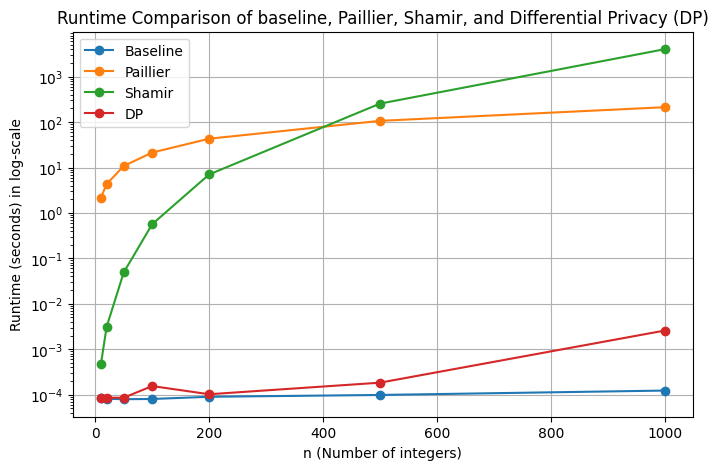

In [69]:
# Generate the plot in log-scale
plt.figure(figsize=(8, 5))
for method in ["Baseline", "Paillier", "Shamir", "DP"]:
    plt.plot(df_results["n"], df_results[method], marker='o', label=method)

plt.xlabel("n (Number of integers)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale('log')
plt.title("Runtime Comparison of baseline, Paillier, Shamir, and Differential Privacy (DP)")
plt.legend()
plt.grid(True)
plt.show()

#### 6.2. Graph comparing accuracy between 4 methods

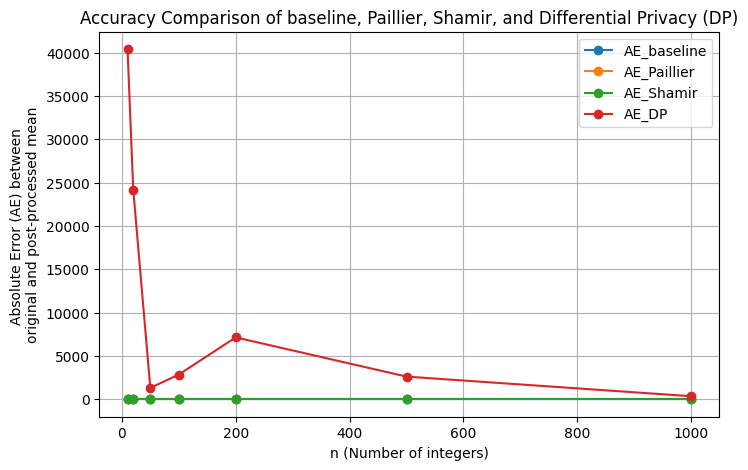

In [70]:
# Generate the plot
plt.figure(figsize=(8, 5))
for method in ["AE_baseline", "AE_Paillier", "AE_Shamir", "AE_DP"]:
    plt.plot(df_results["n"], df_results[method], marker='o', label=method)

plt.xlabel("n (Number of integers)")
plt.ylabel("Absolute Error (AE) between \noriginal and post-processed mean")
plt.title("Accuracy Comparison of baseline, Paillier, Shamir, and Differential Privacy (DP)")
plt.legend()
plt.grid(True)
plt.show()

#### 6.3. Graph comparing runtime between different phases of Paillier

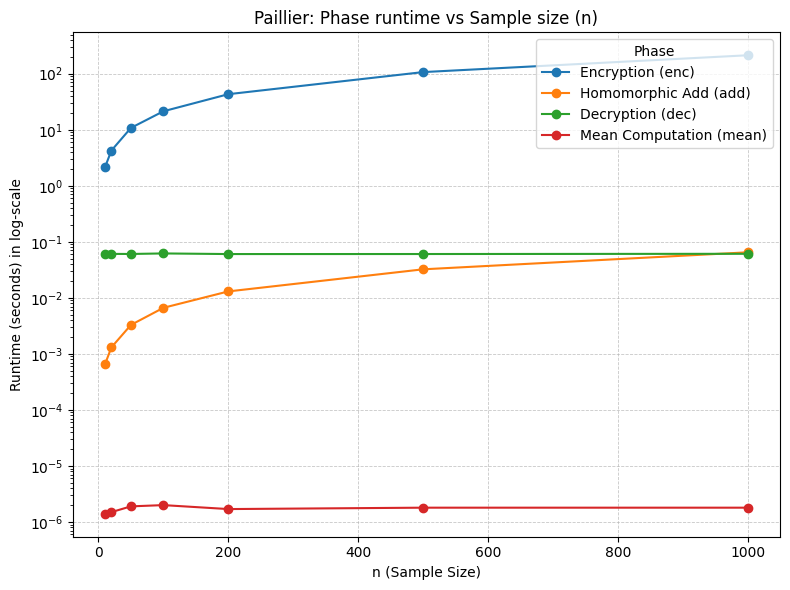

In [71]:
plt.figure(figsize=(8,6))
plt.plot(df_phases["n"], df_phases["Paillier_enc"], marker='o', label="Encryption (enc)")
plt.plot(df_phases["n"], df_phases["Paillier_add"], marker='o', label="Homomorphic Add (add)")
plt.plot(df_phases["n"], df_phases["Paillier_dec"], marker='o', label="Decryption (dec)")
plt.plot(df_phases["n"], df_phases["Paillier_mean"], marker='o', label="Mean Computation (mean)")

plt.title("Paillier: Phase runtime vs Sample size (n)")
plt.xlabel("n (Sample Size)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale("log")
plt.legend(title="Phase")
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

#### 6.4. Graph comparing runtime between different phases of Shamir

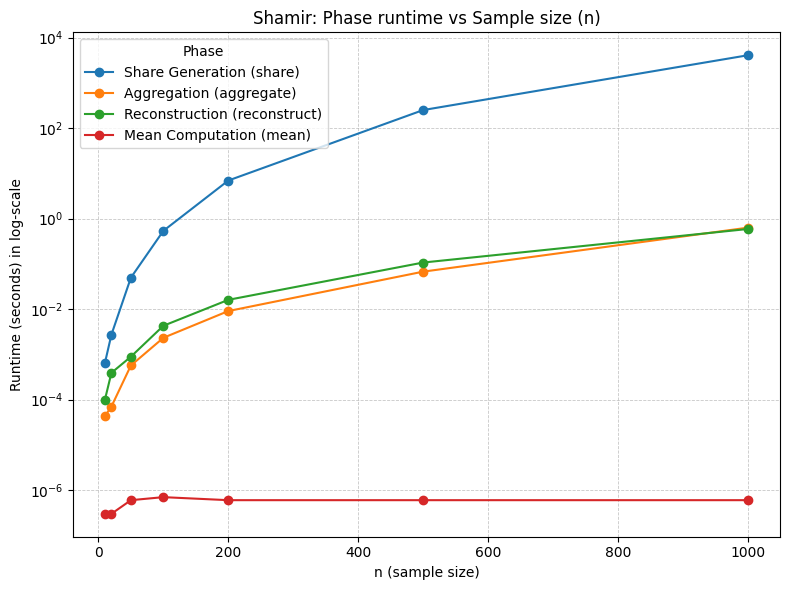

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(df_phases["n"], df_phases["Shamir_share"], marker='o', label="Share Generation (share)")
plt.plot(df_phases["n"], df_phases["Shamir_aggregate"], marker='o', label="Aggregation (aggregate)")
plt.plot(df_phases["n"], df_phases["Shamir_reconstruct"], marker='o', label="Reconstruction (reconstruct)")
plt.plot(df_phases["n"], df_phases["Shamir_mean"], marker='o', label="Mean Computation (mean)")

plt.title("Shamir: Phase runtime vs Sample size (n)")
plt.xlabel("n (sample size)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale("log")
plt.legend(title="Phase")
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

#### 6.5. Graph comparing runtime between different phases of Differential Privacy

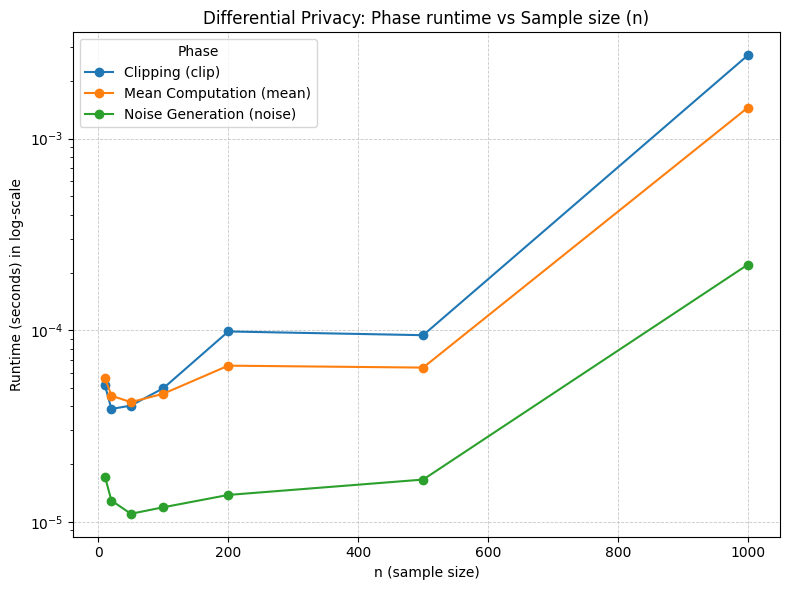

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(df_phases["n"], df_phases["DP_clip"], marker='o', label="Clipping (clip)")
plt.plot(df_phases["n"], df_phases["DP_mean"], marker='o', label="Mean Computation (mean)")
plt.plot(df_phases["n"], df_phases["DP_noise"], marker='o', label="Noise Generation (noise)")

plt.title("Differential Privacy: Phase runtime vs Sample size (n)")
plt.xlabel("n (sample size)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale("log")
plt.legend(title="Phase")
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()